<h2> About the data

| **Feature**    | **Description** |
| :-------- | :------- |
| **cust_id**| Identification of Credit Card holder<br>(Categorical)    |
| **balance**| Balance amount left in their account to make purchases     |
| **balance_frequency**    | How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)    |
| **purchases**    | Amount of purchases made from account |
| **oneoff_purchases**    | Maximum purchase amount done in one-go    |
| **installments_purchases**    | Amount of purchase done in installment    |
| **cash_advance**    | Cash in advance given by the user    |
| **purchases_frequency**    | How frequently the Purchases are being made, score between 0 and 1(1 = frequently purchased, 0 = not frequently purchased)   |
| **oneoff_purchases_frequency**    | How frequently Purchases are happening in one-go(1 = frequently purchased, 0 = not frequently purchased)    |
| **purchases_installments_frequency**    | How frequently purchases in installments are being done(1 = frequently done, 0 = not frequently done)    |
| **cash_advance_frequency**    | How frequently the cash in advance being paid    |
| **cash_advance_trx**    | Number of Transactions made with "Cash in Advanced"(discrete(intiger))   |
| **purchases_trx**    | Number of purchase transactions made<br>(discrete(intiger))   |
| **credit_limit**    | Limit of Credit Card for user  |
| **payments**   | Amount of Payment done by user    |
| **minimum_payments**    | Minimum amount of payments made by user   |
| **prc_full_payment**    | Percent of full payment paid by user  |
| **tenure**    | Tenure of credit card service for user(discrete(integer)) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<h3> Data Preparation

In [2]:
df = pd.read_csv(r'customer_segment.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.drop(columns = 'CUST_ID', inplace = True)

In [4]:
df.shape

(8950, 17)

In [5]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [7]:
df_overview = []
columns = df.columns
for i in columns :
    types = df[i] . dtypes
    unique_data = df[i] . nunique()

    missing_count=df[i].isnull().sum()
    value_count= df[i].isnull().count()
    missing_percentage= round(missing_count/value_count*100,2)

    duplicated= df.duplicated().sum()
    df_overview . append ([i , types , unique_data , missing_count, missing_percentage,duplicated])

df_info = pd . DataFrame (df_overview)
df_info . columns =['name of column' , 'types' ,'unique_data' , 'missing value', "missing percentage","duplicated"]




df_info.style.highlight_max(color = 'aqua', axis = 0)

,name of column,types,unique_data,missing value,missing percentage,duplicated
0,BALANCE,float64,8871,0,0.000000,0
1,BALANCE_FREQUENCY,float64,43,0,0.000000,0
2,PURCHASES,float64,6203,0,0.000000,0
3,ONEOFF_PURCHASES,float64,4014,0,0.000000,0
4,INSTALLMENTS_PURCHASES,float64,4452,0,0.000000,0
5,CASH_ADVANCE,float64,4323,0,0.000000,0
6,PURCHASES_FREQUENCY,float64,47,0,0.000000,0
7,ONEOFF_PURCHASES_FREQUENCY,float64,47,0,0.000000,0
8,PURCHASES_INSTALLMENTS_FREQUENCY,float64,47,0,0.000000,0
9,CASH_ADVANCE_FREQUENCY,float64,54,0,0.000000,0


In [8]:
df.shape

(8950, 17)

<h3> Analyzing Null values

In [9]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [10]:
# Null valu in Credict_limit is only one so we are dropping that
df.dropna(subset = 'CREDIT_LIMIT', inplace = True)

In [11]:
# MINIMUM_PAYMENTS has so much missing value so it is reasonable to find a solution for fill them
df[['PAYMENTS', 'MINIMUM_PAYMENTS']][df['MINIMUM_PAYMENTS'].isna()]

,PAYMENTS,MINIMUM_PAYMENTS
3,0.000000,NaN
45,0.000000,NaN
47,0.000000,NaN
54,417.016763,NaN
55,0.000000,NaN
...,...,...
8919,0.000000,NaN
8929,0.000000,NaN
8935,0.000000,NaN
8944,0.000000,NaN


In [12]:
df_1 = df.copy() # MAking a copy of original dataset for null value transformation.

In [13]:
df_1.fillna(0, inplace = True)

In [14]:
payment_mean = df['PAYMENTS'].mean()

print(f"The mean of the Payment column is : {payment_mean}")

# Use np.where for element-wise conditional filling
df_1['MINIMUM_PAYMENTS'] = np.where(
    df['PAYMENTS'] == 0,
    0,
    np.where(
        (df['PAYMENTS'] > 0) & (df['PAYMENTS'] < payment_mean),
        df['PAYMENTS'],
        payment_mean # Fill with the mean of PAYMENTS for other cases
    )
)

# Verify that there are no more missing values in MINIMUM_PAYMENTS
print(df_1['MINIMUM_PAYMENTS'].isnull().sum())

The mean of the Payment column is : 1733.3365108509329
0


In [15]:
missing_mask = df['PAYMENTS'] > payment_mean

display(df.loc[missing_mask, ['PAYMENTS']].join(df_1.loc[missing_mask, ['MINIMUM_PAYMENTS']]))

,PAYMENTS,MINIMUM_PAYMENTS
1,4103.032597,1733.336511
6,6354.314328,1733.336511
15,1993.439277,1733.336511
21,2077.959051,1733.336511
22,2359.629958,1733.336511
...,...,...
8840,1739.406636,1733.336511
8857,8157.666434,1733.336511
8862,3029.380326,1733.336511
8897,1796.886852,1733.336511


<h3> Analzing the outlier data

In [16]:
df_2 = df_1.copy()

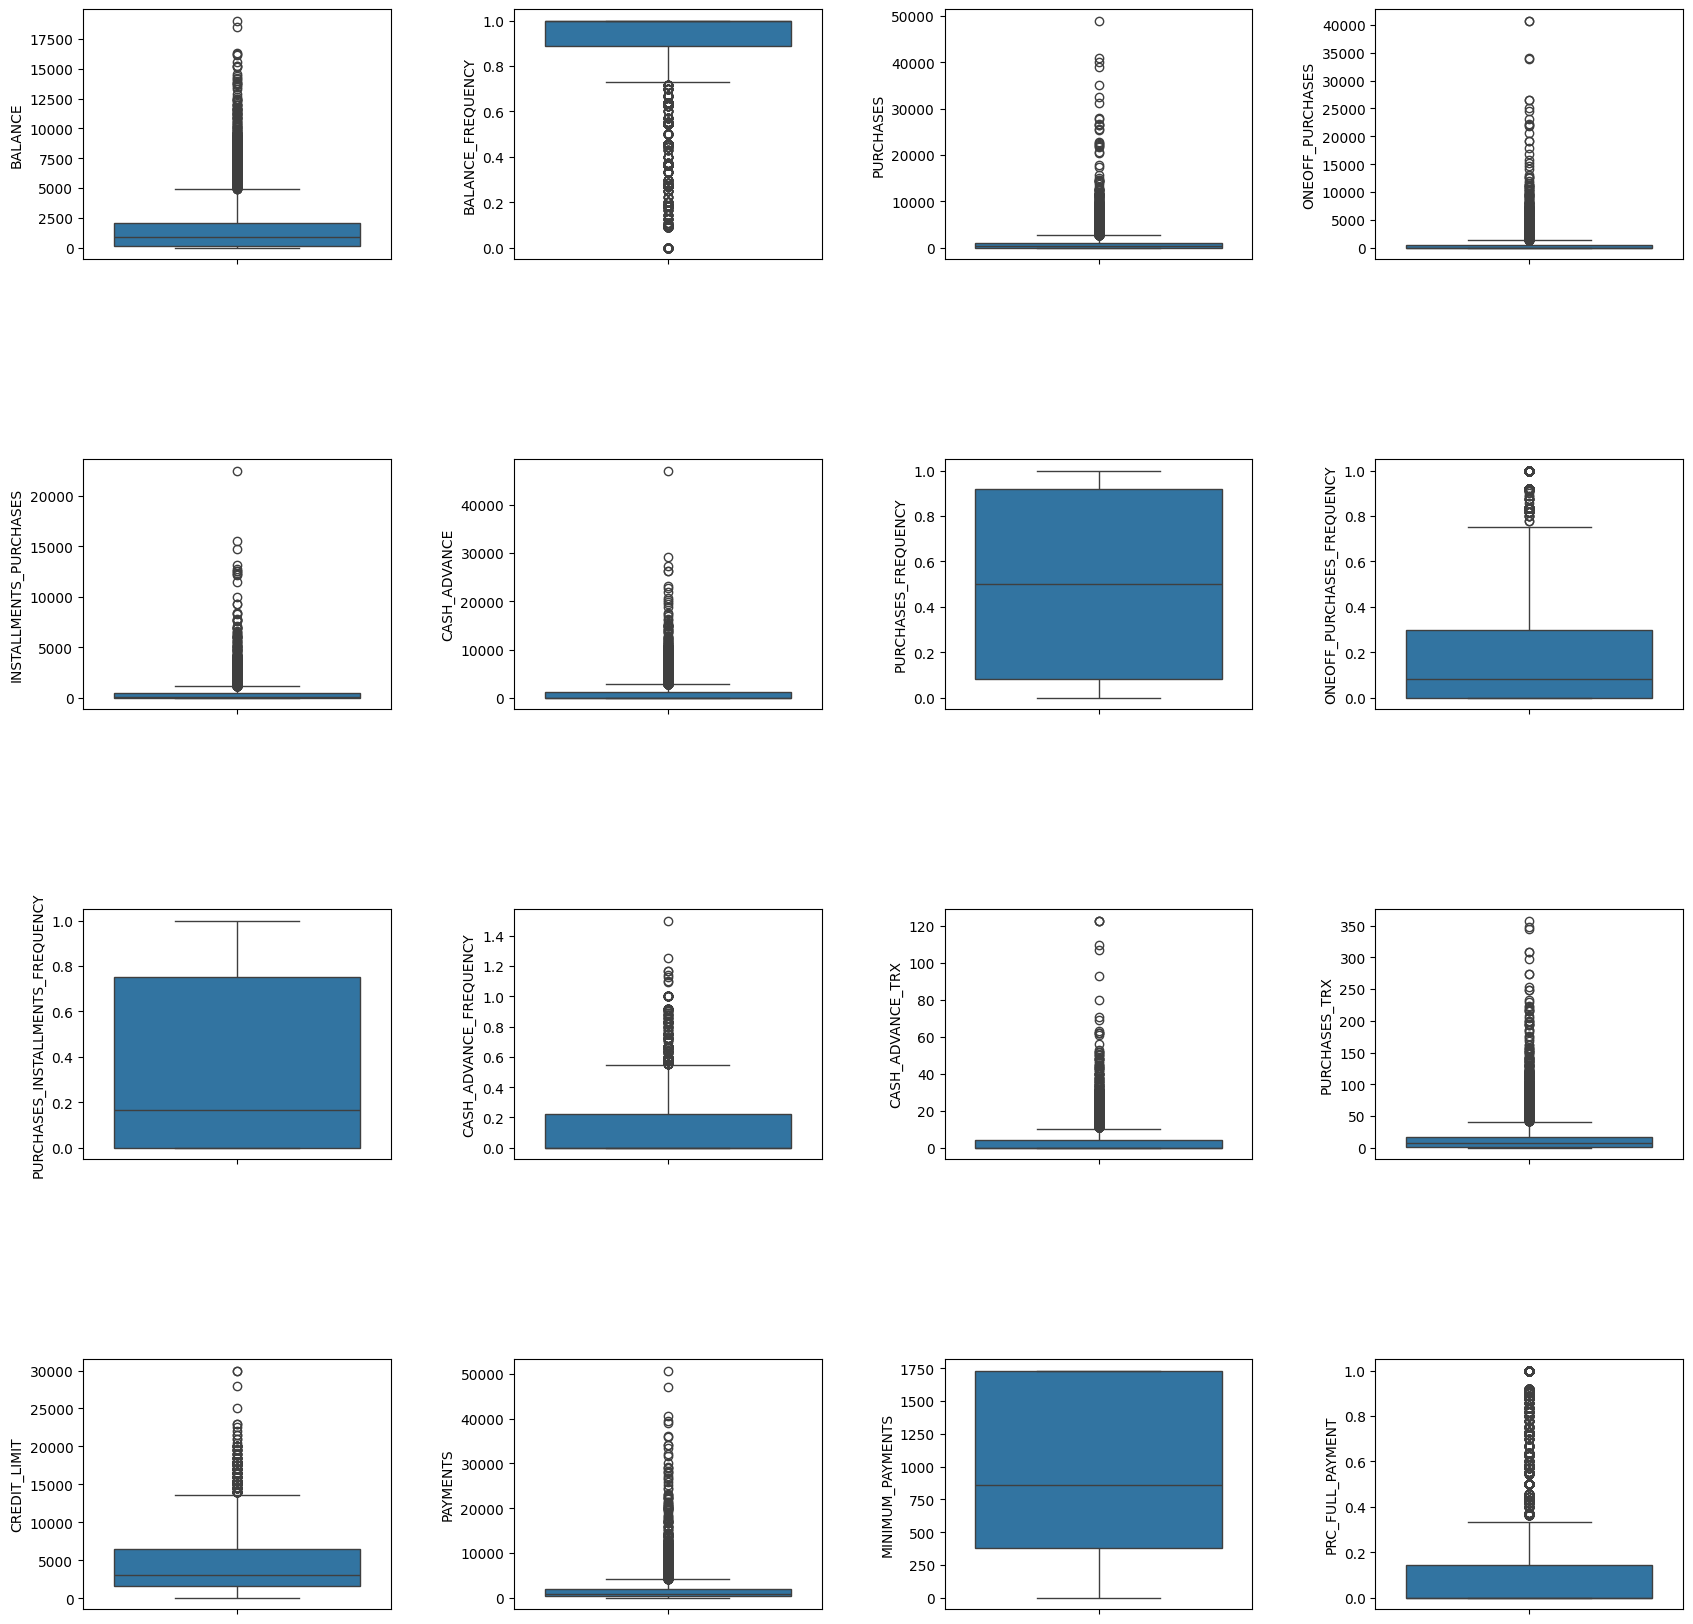

In [17]:

#Using Box plot

plt.subplots(nrows=4 , ncols=4 , figsize=(20,20))
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.8)

for i in range (len(df_2.columns)-1):

    plt.subplot(4,4,i+1)
    sns.boxplot(df_2[df_2.columns[i]])
plt.show()

In [18]:
Q1 = df_2.quantile(0.10)
Q3 = df_2.quantile(0.90)
IQR = Q3 - Q1

count_out = df_2[(df_2 <  (Q1 - 1.5 * IQR)) | (df_2 > (Q3 + 1.5 * IQR))].count()


df_count_out = pd.DataFrame(count_out, columns=['count_out'])
df_count_out

,count_out
BALANCE,54
BALANCE_FREQUENCY,0
PURCHASES,177
ONEOFF_PURCHASES,219
INSTALLMENTS_PURCHASES,170
CASH_ADVANCE,161
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,8


In [19]:
for i in df_2.columns:
  q1 = df_2[i].quantile(0.05)
  q3 = df_2[i].quantile(0.95)
  iqr = q3 - q1
  min = q1 - (1.5 * iqr)
  max = q3 + (1.5 * iqr)
  df_2 = df_2[(df_2[i] >= min) & (df_2[i] <= max)]

In [20]:
print(f"Before removing the outliers : {df_1.shape}")
print(f"After removing the outliers : {df_2.shape}")
loss = df_1.shape[0] - df_2.shape[0]
print(f"Loss of data : {loss} rows")
print(f"% Loss of data : {(loss/df_1.shape[0])*100} %")

Before removing the outliers : (8949, 17)
After removing the outliers : (8625, 17)
Loss of data : 324 rows
% Loss of data : 3.6205162587998654 %


For 0.1 and 0.9 We will loss 13% data.

So are sticking with 0.05 and 0.95 for quantiles.

<h2> Modelling

In [21]:
df = df_2.copy()

<Axes: >

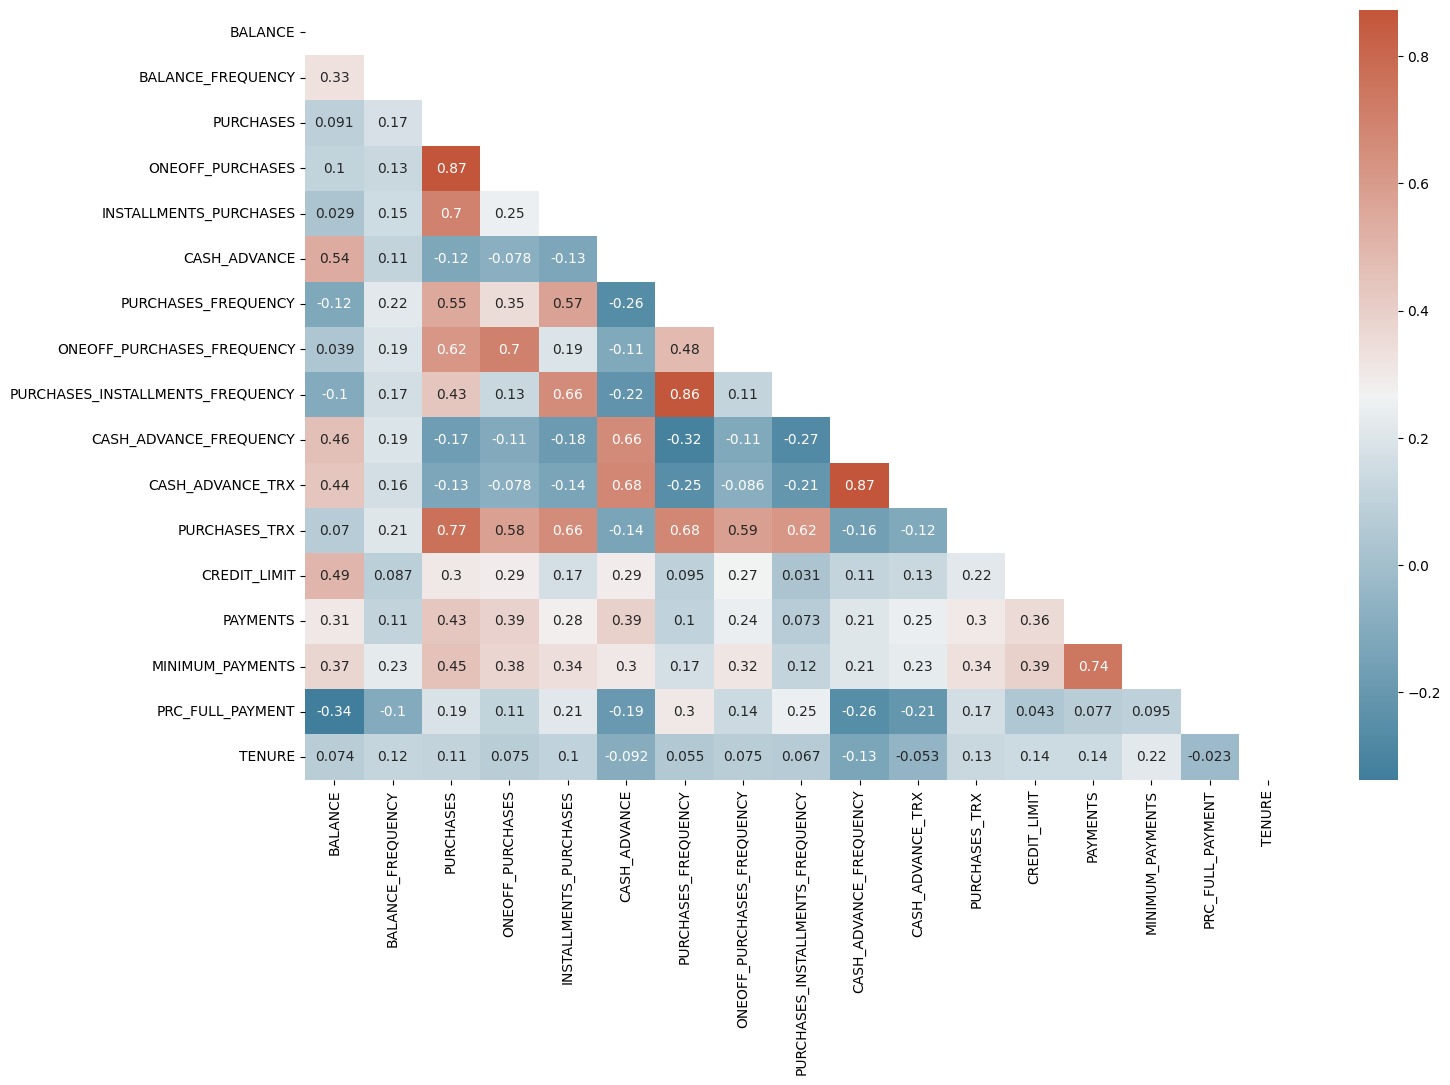

In [22]:
corr = df.corr()

f, ax = plt.subplots(figsize=(16, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

In [23]:
from sklearn.preprocessing import StandardScaler
df_model=df.copy()

scaler= StandardScaler()
df_Standardize=pd.DataFrame(scaler.fit_transform(df_model), columns = df_model.columns)
df_Standardize

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.743593,-0.238537,-0.610791,-0.529321,-0.428817,-0.533364,-0.791370,-0.664816,-0.695994,-0.682144,-0.566954,-0.605727,-0.965594,-0.721486,-1.189549,-0.517466,0.364006
1,0.907983,0.142774,-0.695061,-0.529321,-0.594616,3.461364,-1.208661,-0.664816,-0.907227,0.627951,0.221339,-0.719999,0.797389,1.637756,1.316701,0.251573,0.364006
2,0.538486,0.524086,-0.012095,0.390428,-0.594616,-0.533364,1.295084,2.805114,-0.907227,-0.682144,-0.566954,-0.034368,0.944304,-0.467334,-0.501815,-0.517466,0.364006
3,0.105696,-1.001159,0.629054,1.253862,-0.594616,-0.405772,-1.000017,-0.375657,-0.907227,-0.245447,-0.369881,-0.662863,0.944304,-0.843524,-1.519784,-0.517466,0.364006
4,-0.337792,0.524086,-0.680928,-0.510288,-0.594616,-0.533364,-1.000017,-0.375657,-0.907227,-0.682144,-0.566954,-0.662863,-0.906828,-0.433306,-0.409736,-0.517466,0.364006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8620,-0.750074,0.524086,-0.437906,-0.529321,-0.088667,-0.533364,1.295084,-0.664816,1.205105,-0.682144,-0.566954,-0.377183,-0.965594,-0.646623,-0.986971,1.212874,-4.090314
8621,-0.754938,0.524086,-0.430062,-0.529321,-0.073234,-0.533364,1.295084,-0.664816,1.205105,-0.682144,-0.566954,-0.377183,-0.965594,-0.676699,-1.068356,-0.517466,-4.090314
8622,-0.752736,-0.174987,-0.567508,-0.529321,-0.343658,-0.533364,0.877792,-0.664816,0.782641,-0.682144,-0.566954,-0.434319,-0.965594,-0.794376,-1.386790,0.347704,-4.090314
8623,-0.757929,-0.174987,-0.695061,-0.529321,-0.594616,-0.510697,-1.208661,-0.664816,-0.907227,0.191254,-0.172807,-0.719999,-1.112510,-0.811745,-1.433789,0.347704,-4.090314


In [24]:
from sklearn.cluster import KMeans

In [25]:
X = df_Standardize

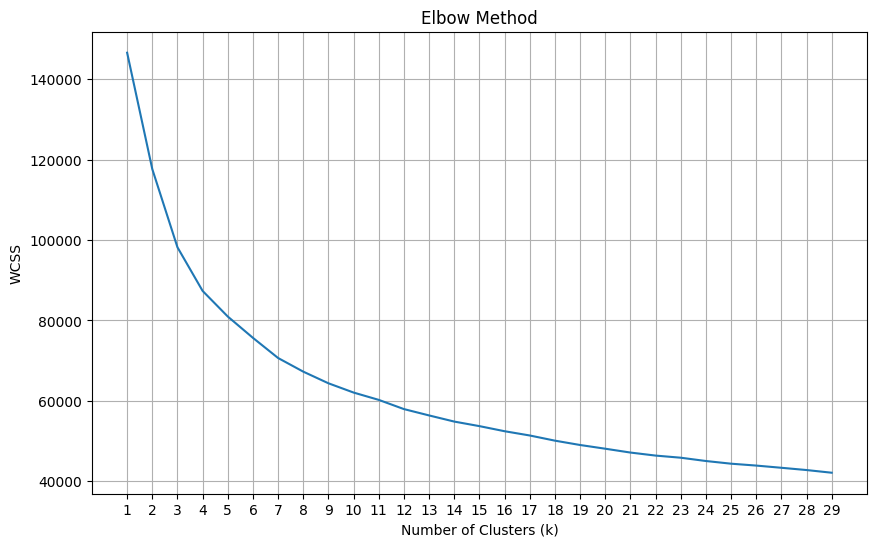

In [26]:
wcss = []
for i in range(1, 30):  # Test k from 1 to 29
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the WCSS values
plt.figure(figsize=(10, 6))
plt.plot(range(1, 30), wcss) # Corrected the range to match the number of WCSS values
plt.title('Elbow Method')
plt.xticks(range(1, 30))
plt.grid(True)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

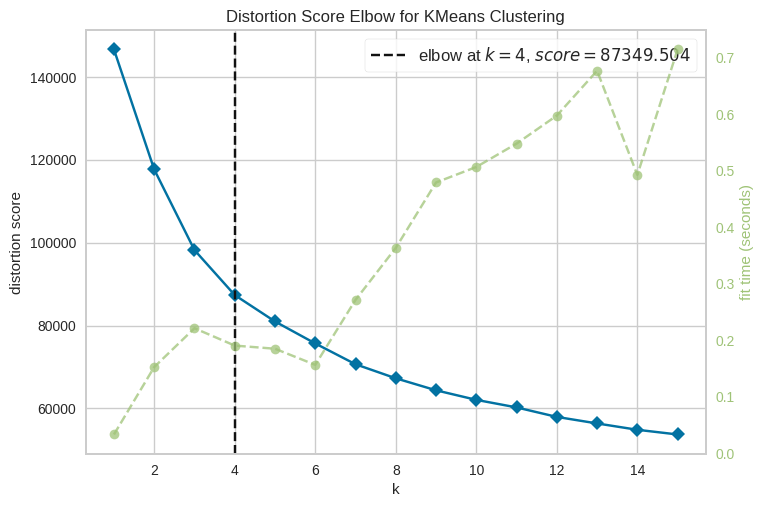

Optimal k (elbow point): 4


In [27]:
# Identifying the elbow point
from yellowbrick.cluster import KElbowVisualizer
visualizer = KElbowVisualizer(kmeans, k=(1,16))
visualizer.fit(X)
visualizer.show()
print(f"Optimal k (elbow point): {visualizer.elbow_value_}")

In [39]:
kmean= KMeans(4)
kmean.fit(X)
labels_kmean = kmean.labels_

In [29]:
clusters=pd.concat([df_model, pd.DataFrame({'cluster':labels})], axis=1)
clusters.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,201.802084,0.000000,12.0,3.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1733.336511,0.222222,12.0,2.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,622.066742,0.000000,12.0,1.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,0.000000,0.000000,12.0,3.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,678.334763,0.000000,12.0,3.0


In [30]:
cluster_0 = clusters[clusters['cluster'] == 0]
cluster_1 = clusters[clusters['cluster'] == 1]
cluster_2 = clusters[clusters['cluster'] == 2]
cluster_3 = clusters[clusters['cluster'] == 3]


In [31]:
cluster_0_summary = cluster_0.describe().loc[['mean', 'std', 'max']].T
cluster_1_summary = cluster_1.describe().loc[['mean', 'std', 'max']].T
cluster_2_summary = cluster_2.describe().loc[['mean', 'std', 'max']].T
cluster_3_summary = cluster_3.describe().loc[['mean', 'std', 'max']].T

cluster_0_summary.columns = ['cluster_0_mean', 'cluster_0_std', 'cluster_0_max']
cluster_1_summary.columns = ['cluster_1_mean', 'cluster_1_std', 'cluster_1_max']
cluster_2_summary.columns = ['cluster_2_mean', 'cluster_2_std', 'cluster_2_max']
cluster_3_summary.columns = ['cluster_3_mean', 'cluster_3_std', 'cluster_3_max']

final_summary = pd.concat([cluster_0_summary, cluster_1_summary, cluster_2_summary, cluster_3_summary], axis=1)

final_summary

,cluster_0_mean,cluster_0_std,cluster_0_max,cluster_1_mean,cluster_1_std,cluster_1_max,cluster_2_mean,cluster_2_std,cluster_2_max,cluster_3_mean,cluster_3_std,cluster_3_max
BALANCE,1602.711770,1981.595775,14411.957980,1443.685161,1956.150695,14224.115410,1572.184099,2026.927152,12596.421940,1488.897926,1867.124391,13968.479570
BALANCE_FREQUENCY,0.890408,0.220952,1.000000,0.876981,0.238961,1.000000,0.877357,0.241247,1.000000,0.874977,0.238616,1.000000
PURCHASES,895.191709,1254.257978,7387.830000,765.126555,1115.290671,8581.290000,808.983333,1098.059727,6842.230000,794.489764,1147.329641,9751.900000
ONEOFF_PURCHASES,536.559637,908.974847,6099.080000,431.531980,835.674021,5910.040000,463.482900,813.492377,6157.740000,444.549390,853.166131,6120.400000
INSTALLMENTS_PURCHASES,358.999391,616.119704,4037.210000,333.890398,552.074490,4092.670000,345.872159,577.853873,3816.000000,349.994027,593.927910,4127.830000
CASH_ADVANCE,926.169574,1785.702550,11549.111740,836.830203,1569.065810,11070.566230,849.772089,1618.641920,11220.766360,882.638102,1616.236874,11173.775870
PURCHASES_FREQUENCY,0.494349,0.397924,1.000000,0.480050,0.401358,1.000000,0.483824,0.394682,1.000000,0.476064,0.398484,1.000000
ONEOFF_PURCHASES_FREQUENCY,0.223128,0.307976,1.000000,0.187045,0.288748,1.000000,0.206996,0.295006,1.000000,0.189719,0.284802,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,0.362290,0.392121,1.000000,0.359791,0.397493,1.000000,0.352303,0.390071,1.000000,0.350740,0.393709,1.000000
CASH_ADVANCE_FREQUENCY,0.127210,0.193988,1.166667,0.131052,0.191545,1.090909,0.135271,0.196491,1.000000,0.128996,0.187249,1.250000


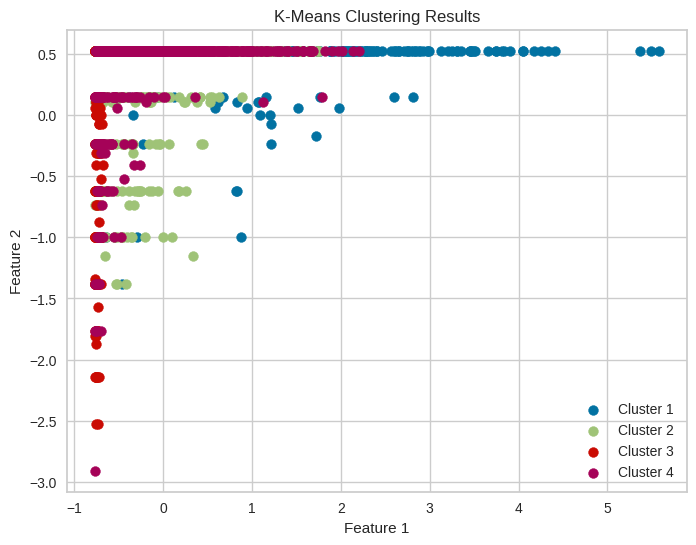

In [32]:
y_kmeans = kmeans.predict(X) # Get cluster assignments for each data point
plt.figure(figsize=(8, 6))

# Plot data points colored by cluster
for i in range(4):
  plt.scatter(X.iloc[y_kmeans == i, 0], X.iloc[y_kmeans == i, 1], s=50, label=f'Cluster {i+1}')

plt.title('K-Means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

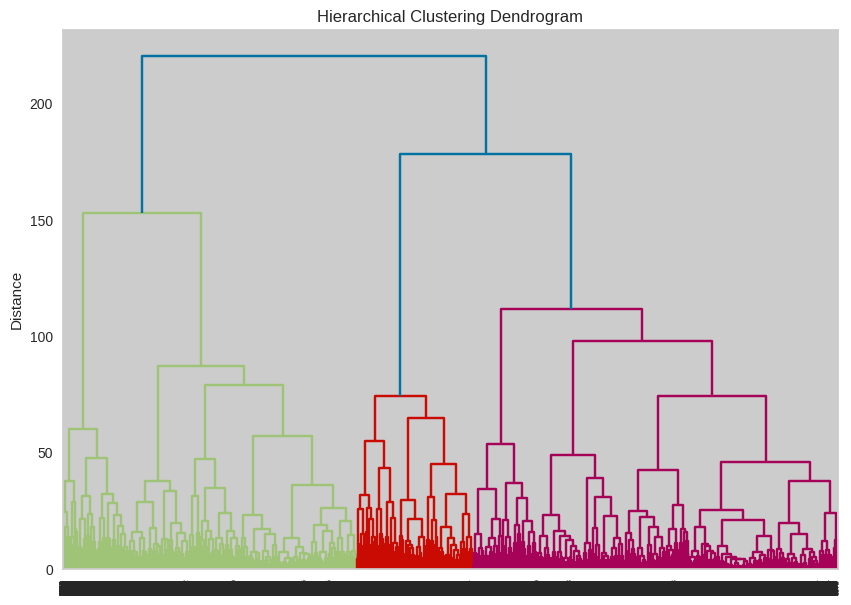

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X, method='ward')

# Plotting the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.ylabel("Distance")
plt.show()


Types of Hierarchical Clustering

There are two main types of hierarchical clustering.

1. Agglomerative Clustering

2. Divisive clustering

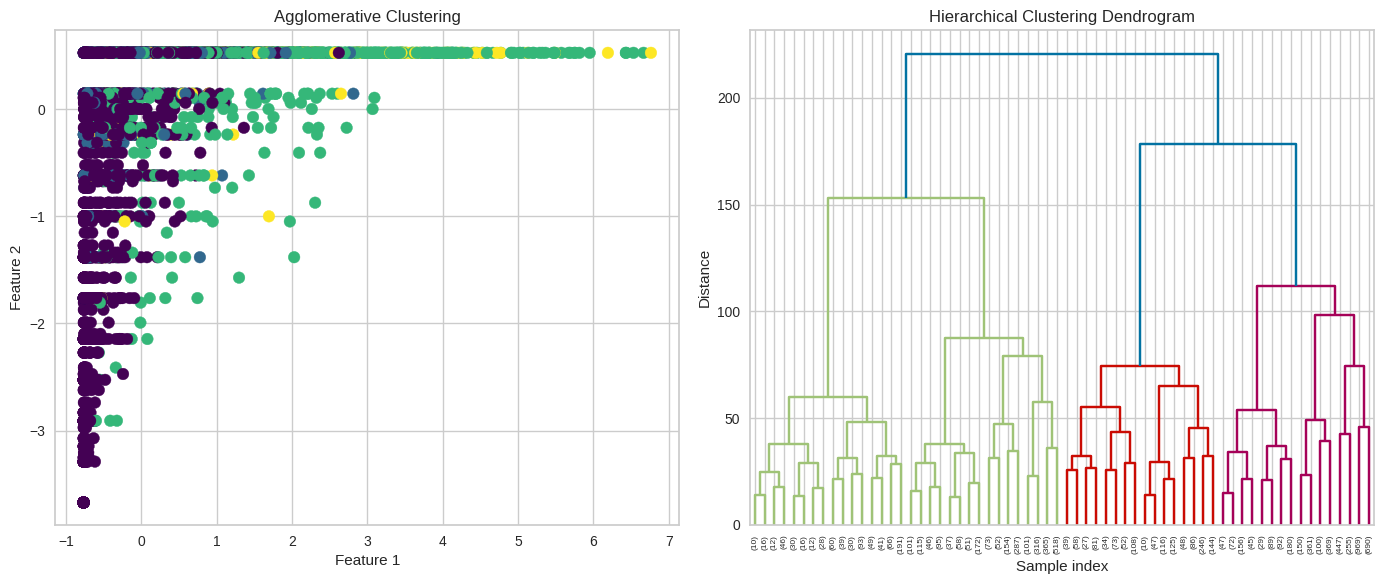

In [44]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

agg_model = AgglomerativeClustering(n_clusters=4)
labels_agg = agg_model.fit_predict(X)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels_agg, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

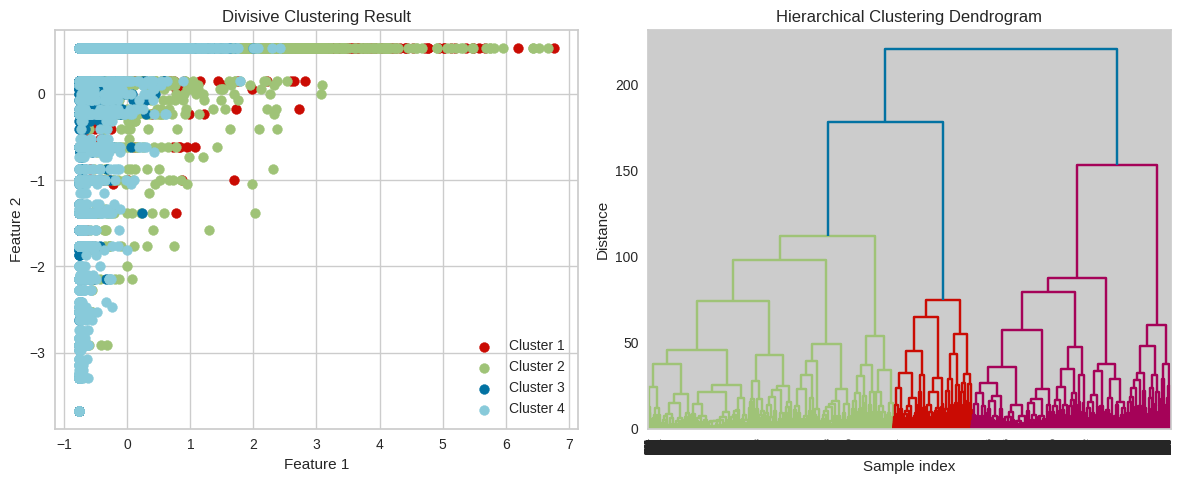

In [35]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

def divisive_clustering(data, max_clusters=4):
    # Initialize with a single cluster containing all data
    clusters = [data]

    while len(clusters) < max_clusters:
        # Find the largest cluster to split
        largest_cluster_index = 0
        largest_cluster_size = 0
        for i, cluster in enumerate(clusters):
            if cluster.shape[0] > largest_cluster_size:
                largest_cluster_size = cluster.shape[0]
                largest_cluster_index = i

        cluster_to_split = clusters.pop(largest_cluster_index)

        # Perform KMeans with 2 clusters on the selected cluster
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(cluster_to_split)

        # Split the cluster and add the new clusters to the list
        cluster1 = cluster_to_split[kmeans.labels_ == 0]
        cluster2 = cluster_to_split[kmeans.labels_ == 1]

        clusters.extend([cluster1, cluster2])

    return clusters

# Perform divisive clustering
clusters_divisive = divisive_clustering(X, max_clusters=4)

# Plot Divisive Clustering Result
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['r', 'g', 'b', 'c', 'm', 'y']
for i, cluster in enumerate(clusters_divisive):
    plt.scatter(cluster.iloc[:, 0], cluster.iloc[:, 1], s=50,
                c=colors[i % len(colors)], label=f'Cluster {i+1}') # Use modulo for color cycling
plt.title('Divisive Clustering Result')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot Hierarchical Clustering Dendrogram (Agglomerative)
linked = linkage(X, method='ward') # Assuming X is your original data or standardized data

plt.subplot(1, 2, 2)
dendrogram(linked, orientation='top',
           distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

<h3> Evaluation of models

In [40]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# For KMean
silhouette = silhouette_score(X, labels_kmean)
calinski = calinski_harabasz_score(X, labels_kmean)
davies = davies_bouldin_score(X, labels_kmean)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski)
print("Davies-Bouldin Index:", davies)

Silhouette Score: 0.21798251728758203
Calinski-Harabasz Index: 1714.6840393421774
Davies-Bouldin Index: 1.544558122219305


In [45]:
# For agg
silhouette = silhouette_score(X, labels_agg)
calinski = calinski_harabasz_score(X, labels_agg)
davies = davies_bouldin_score(X, labels_agg)

# 4. Print scores
print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Index:", calinski)
print("Davies-Bouldin Index:", davies)

Silhouette Score: 0.15341089143598322
Calinski-Harabasz Index: 1577.6984157822317
Davies-Bouldin Index: 1.7897192953980763


In [47]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)


labels_filtered = labels_dbscan[labels_dbscan != -1]
X_filtered = X[labels_dbscan != -1]

silhouette = silhouette_score(X_filtered, labels_filtered) if len(labels_filtered) > 1 else -1
calinski = calinski_harabasz_score(X_filtered, labels_filtered) if len(labels_filtered) > 1 else -1
davies = davies_bouldin_score(X_filtered, labels_filtered) if len(labels_filtered) > 1 else -1

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")


Silhouette Score: -0.2913
Calinski-Harabasz Index: 45.6798
Davies-Bouldin Index: 1.4108


<h3>For Now Kmean at cluster number = 4 is best